# IMPORTING DATASETS AND PACKAGES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [4]:
crops_df=pd.read_csv("../Crop_recommendation.csv")

In [6]:
crops_df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [14]:
crops_df=crops_df.rename(columns={'label':'crops'})

In [16]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le=LabelEncoder()

In [20]:
y = le.fit_transform(crops_df["crops"])

In [22]:
# Map encoded labels back to crop names
for i, crop in enumerate(le.classes_):
    print(f"{i} -> {crop}")

0 -> apple
1 -> banana
2 -> blackgram
3 -> chickpea
4 -> coconut
5 -> coffee
6 -> cotton
7 -> grapes
8 -> jute
9 -> kidneybeans
10 -> lentil
11 -> maize
12 -> mango
13 -> mothbeans
14 -> mungbean
15 -> muskmelon
16 -> orange
17 -> papaya
18 -> pigeonpeas
19 -> pomegranate
20 -> rice
21 -> watermelon


# Model - 1

In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Split
X = crops_df.drop('crops', axis=1)
# y = crops_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', num_class=len(np.unique(y)), random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9863636363636363
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.96      0.96      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       0.95      1.00      0.97        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        1

In [33]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation mean accuracy:", scores.mean())

Cross-validation mean accuracy: 0.9927272727272728


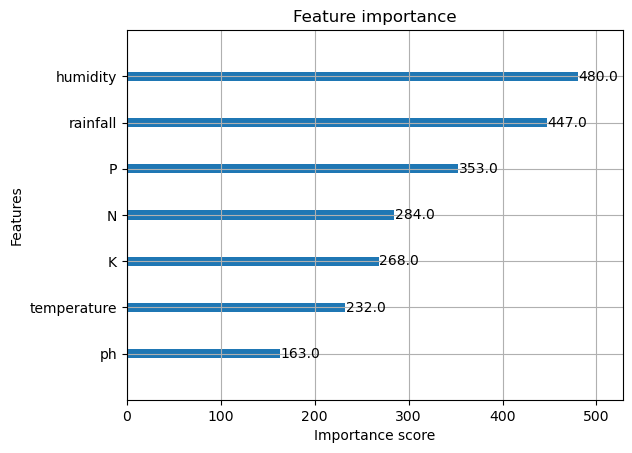

In [44]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model)
plt.show()

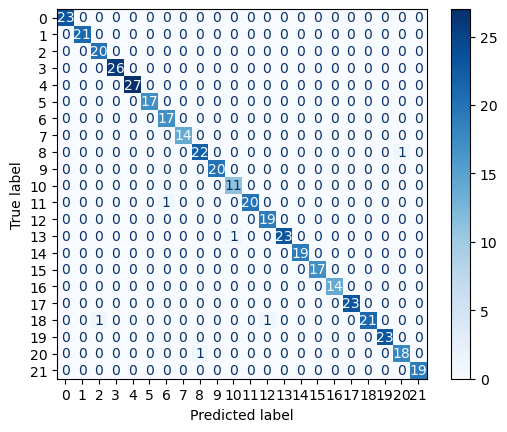

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap='Blues')

# Model - 2 ( GridSearchCV )

In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [50]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

In [52]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

In [54]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [56]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1,        # use all CPU cores
    cv=cv,
    verbose=2
)

grid_search.fit(X, y)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


C:\Users\vasug\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:23:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=22, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, 0.3],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=2)

In [66]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}
Best cross-validation accuracy: 0.9959090909090909


In [60]:
best_model = grid_search.best_estimator_

In [62]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       1.00      1.00      1.00        23
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
        

# Export Model

In [70]:
import joblib

In [72]:
joblib.dump(best_model, "xgb_crop_model.pkl")

['xgb_crop_model.pkl']

In [74]:
best_params = grid_search.best_params_
joblib.dump(best_params, 'best_params_xgb.pkl')

['best_params_xgb.pkl']

In [76]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']

# Predict new input

In [83]:
test_samples = [
    [120, 55, 30, 25.4, 70.2, 6.2, 85.0],    # maize
    [85, 58, 60, 27.5, 65.0, 7.0, 60.5],     # cotton
    [100, 35, 30, 25.5, 65.0, 6.8, 150.0],   # coffee
    [70, 50, 40, 28.0, 70.0, 6.7, 120.0],    # mango
    [110, 45, 38, 27.8, 85.0, 6.6, 200.0]    # banana
]

preds = model.predict(test_samples)
print("Predicted crops:", le.inverse_transform(preds))

Predicted crops: ['cotton' 'blackgram' 'coffee' 'jute' 'rice']


# Accuracy

normal Accuracy

Training Accuracy: 1.0000
Cross-Validation Accuracy: 0.9875 (+/- 0.0058)
Test Accuracy: 0.9864

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.96      0.96      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       0.95      1.00      0.97        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon    

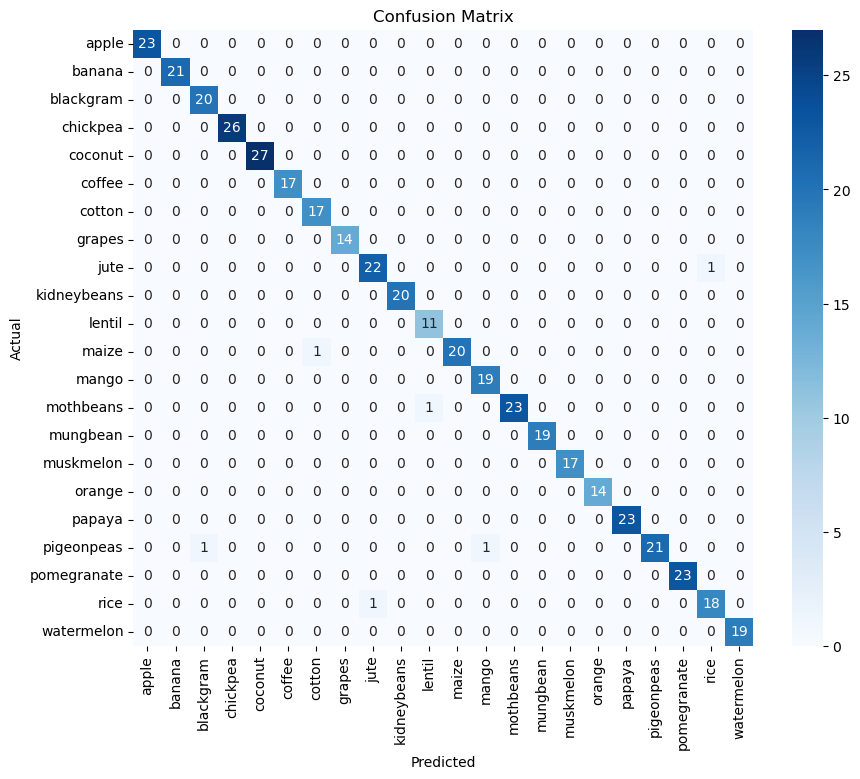


Per-Class Accuracy:
apple           : 1.0000
banana          : 1.0000
blackgram       : 1.0000
chickpea        : 1.0000
coconut         : 1.0000
coffee          : 1.0000
cotton          : 1.0000
grapes          : 1.0000
jute            : 0.9565
kidneybeans     : 1.0000
lentil          : 1.0000
maize           : 0.9524
mango           : 1.0000
mothbeans       : 0.9583
mungbean        : 1.0000
muskmelon       : 1.0000
orange          : 1.0000
papaya          : 1.0000
pigeonpeas      : 0.9130
pomegranate     : 1.0000
rice            : 0.9474
watermelon      : 1.0000


In [85]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 1. Training accuracy
train_preds = model.predict(X_train)
train_acc = accuracy_score(y_train, train_preds)
print(f"Training Accuracy: {train_acc:.4f}")

# ✅ 2. Cross-validation accuracy (mean & std)
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ✅ 3. Test accuracy
test_preds = model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")

# ✅ 4. Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=le.classes_))

# ✅ 5. Confusion matrix (visual)
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ 6. Per-class accuracy (optional but insightful)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_results = dict(zip(le.classes_, per_class_acc))
print("\nPer-Class Accuracy:")
for crop, acc in per_class_results.items():
    print(f"{crop:15s} : {acc:.4f}")


GridSearchCV accuracy

Training Accuracy: 1.0000


C:\Users\vasug\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:48:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\vasug\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:48:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\vasug\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:48:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\vasug\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:48:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

Cross-Validation Accuracy: 0.9932 (+/- 0.0073)
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       1.00      1.00      1.00        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      1.00        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.0

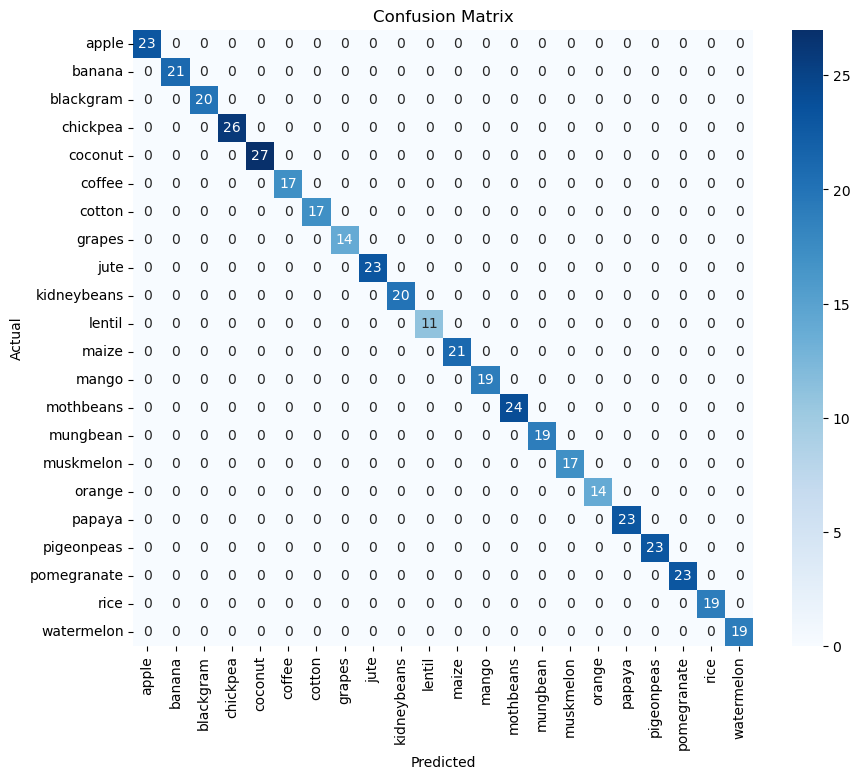


Per-Class Accuracy:
apple           : 1.0000
banana          : 1.0000
blackgram       : 1.0000
chickpea        : 1.0000
coconut         : 1.0000
coffee          : 1.0000
cotton          : 1.0000
grapes          : 1.0000
jute            : 1.0000
kidneybeans     : 1.0000
lentil          : 1.0000
maize           : 1.0000
mango           : 1.0000
mothbeans       : 1.0000
mungbean        : 1.0000
muskmelon       : 1.0000
orange          : 1.0000
papaya          : 1.0000
pigeonpeas      : 1.0000
pomegranate     : 1.0000
rice            : 1.0000
watermelon      : 1.0000


In [87]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 1. Training accuracy
train_preds = best_model.predict(X_train)
train_acc = accuracy_score(y_train, train_preds)
print(f"Training Accuracy: {train_acc:.4f}")

# ✅ 2. Cross-validation accuracy (mean & std)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ✅ 3. Test accuracy
test_preds = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")

# ✅ 4. Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=le.classes_))

# ✅ 5. Confusion matrix (visual)
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ 6. Per-class accuracy (optional but insightful)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_results = dict(zip(le.classes_, per_class_acc))
print("\nPer-Class Accuracy:")
for crop, acc in per_class_results.items():
    print(f"{crop:15s} : {acc:.4f}")